# Model Training: Explainable Audio Deepfake Detection

This notebook focuses on training multiple deep learning models for audio deepfake detection.  
We implement and compare three architectures:

- Baseline CNN
- CNN with Dropout (regularization)
- CNN with Attention (enhanced feature focus)

The goal is to evaluate how architectural changes impact performance and interpretability.

## 1. Import Libraries

We import libraries required for deep learning, audio processing, and data handling.

In [1]:
import os
import random
import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

## 2. Configuration

Define dataset paths and model parameters.

In [2]:
DATA_PATH = "../data/ASVspoof2019_LA"
PROTOCOL_PATH = os.path.join(DATA_PATH, "ASVspoof2019_LA_cm_protocols")

SR = 16000
DURATION = 3
N_MELS = 128
IMG_SIZE = 128

BATCH_SIZE = 16
EPOCHS = 10

## 3. Device Setup

We use GPU acceleration (MPS on Apple Silicon) when available.

In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


## 4. Load Dataset

We parse the protocol file and prepare training data.

In [4]:
def parse_protocol(file_path):
    files, labels = [], []

    with open(file_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            files.append(parts[1])
            labels.append(1 if parts[-1] == "spoof" else 0)

    return files, labels

train_protocol = os.path.join(PROTOCOL_PATH, "ASVspoof2019.LA.cm.train.trn.txt")

filenames, labels = parse_protocol(train_protocol)

subset_size = 1500
combined = list(zip(filenames, labels))
random.shuffle(combined)
combined = combined[:subset_size]

filenames, labels = zip(*combined)

files = [
    os.path.join(DATA_PATH, "ASVspoof2019_LA_train/flac", f"{f}.flac")
    for f in filenames
]

labels = list(labels)

## 5. Train-Validation Split

In [5]:
train_files, val_files, train_labels, val_labels = train_test_split(
    files, labels, test_size=0.2, stratify=labels
)

## 6. Audio Preprocessing

Convert audio into Mel spectrograms.

In [6]:
def audio_to_mel(path):
    y, _ = librosa.load(path, sr=SR)

    max_len = SR * DURATION
    y = y[:max_len] if len(y) > max_len else np.pad(y, (0, max_len - len(y)))

    mel = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS)
    mel = librosa.power_to_db(mel, ref=np.max)

    mel = (mel - mel.mean()) / (mel.std() + 1e-6)
    mel = cv2.resize(mel, (IMG_SIZE, IMG_SIZE))

    return mel

## 7. Dataset Class

In [7]:
class AudioDataset(Dataset):
    def __init__(self, files, labels):
        self.files = files
        self.labels = labels

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        mel = audio_to_mel(self.files[idx])
        mel = torch.tensor(mel, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return mel, label

## 8. DataLoaders

In [8]:
train_loader = DataLoader(AudioDataset(train_files, train_labels), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(AudioDataset(val_files, val_labels), batch_size=BATCH_SIZE)

## 9. Model Architectures

We implement three models for comparison:
- CNN (baseline)
- CNN + Dropout
- CNN + Attention

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(32*32*32,128)
        self.fc2 = nn.Linear(128,2)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [10]:
class CNN_Dropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3)

        self.fc1 = nn.Linear(32*32*32,128)
        self.fc2 = nn.Linear(128,2)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0),-1)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

In [11]:
class CNN_Attention(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.pool = nn.MaxPool2d(2)

        self.attention = nn.Conv2d(32,32,1)

        self.fc1 = nn.Linear(32*32*32,128)
        self.fc2 = nn.Linear(128,2)

    def forward(self,x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.conv2(x)

        attn = torch.sigmoid(self.attention(x))
        x = x * attn

        x = self.pool(F.relu(x))

        x = x.view(x.size(0),-1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

## 10. Training Function

In [12]:
def evaluate(model):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            preds = torch.argmax(model(X), dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [13]:
def train_model(model, name="Model"):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    losses, accs = [], []

    print(f"\nTraining {name}\n" + "-"*40)

    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        val_acc = evaluate(model)

        losses.append(avg_loss)
        accs.append(val_acc)

        print(f"Epoch {epoch+1:02d} | Loss: {avg_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    return model, losses, accs

## 11. Train Models

In [14]:
cnn_model, cnn_loss, cnn_acc = train_model(CNN(), "CNN")
drop_model, drop_loss, drop_acc = train_model(CNN_Dropout(), "CNN + Dropout")
attn_model, attn_loss, attn_acc = train_model(CNN_Attention(), "CNN + Attention")


Training CNN
----------------------------------------
Epoch 01 | Loss: 0.2949 | Val Acc: 91.33%
Epoch 02 | Loss: 0.1638 | Val Acc: 93.00%
Epoch 03 | Loss: 0.1022 | Val Acc: 97.00%
Epoch 04 | Loss: 0.0511 | Val Acc: 97.00%
Epoch 05 | Loss: 0.0250 | Val Acc: 97.00%
Epoch 06 | Loss: 0.0187 | Val Acc: 97.33%
Epoch 07 | Loss: 0.0029 | Val Acc: 96.33%
Epoch 08 | Loss: 0.0007 | Val Acc: 97.00%
Epoch 09 | Loss: 0.0004 | Val Acc: 97.33%
Epoch 10 | Loss: 0.0003 | Val Acc: 96.67%

Training CNN + Dropout
----------------------------------------
Epoch 01 | Loss: 0.3338 | Val Acc: 89.33%
Epoch 02 | Loss: 0.2162 | Val Acc: 91.33%
Epoch 03 | Loss: 0.1373 | Val Acc: 94.67%
Epoch 04 | Loss: 0.0679 | Val Acc: 96.67%
Epoch 05 | Loss: 0.0268 | Val Acc: 97.00%
Epoch 06 | Loss: 0.0153 | Val Acc: 97.33%
Epoch 07 | Loss: 0.0153 | Val Acc: 98.33%
Epoch 08 | Loss: 0.0041 | Val Acc: 98.67%
Epoch 09 | Loss: 0.0026 | Val Acc: 97.33%
Epoch 10 | Loss: 0.0275 | Val Acc: 98.33%

Training CNN + Attention
--------------

## 12. Training Curves

In [17]:
def plot_training(loss, acc, title):
    epochs = range(1, len(loss)+1)

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(epochs, loss)
    plt.title(f"{title} - Loss")

    plt.subplot(1,2,2)
    plt.plot(epochs, acc)
    plt.title(f"{title} - Validation Accuracy")

    plt.show()

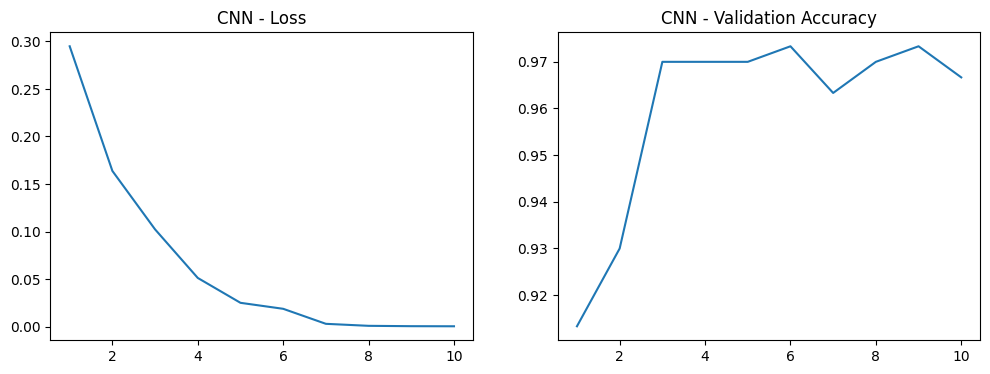

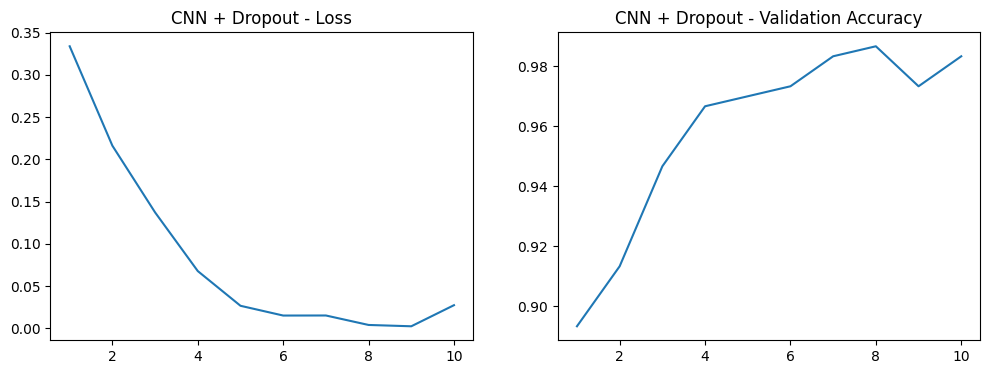

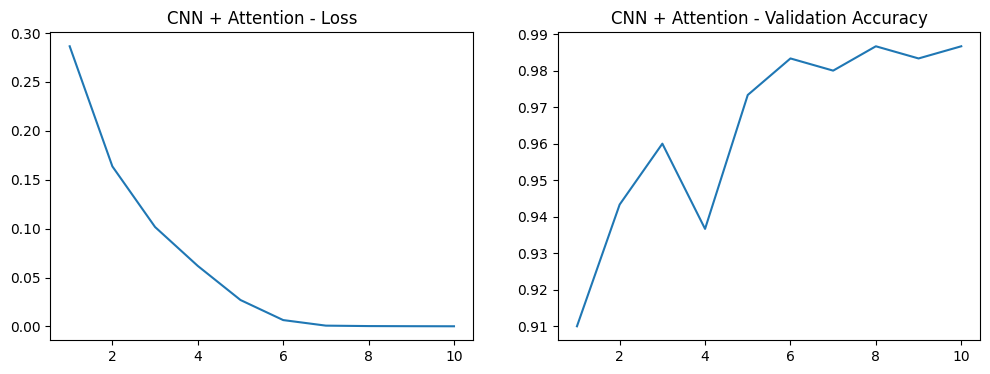

In [18]:
plot_training(cnn_loss, cnn_acc, "CNN")
plot_training(drop_loss, drop_acc, "CNN + Dropout")
plot_training(attn_loss, attn_acc, "CNN + Attention")

## 13. Model Comparison

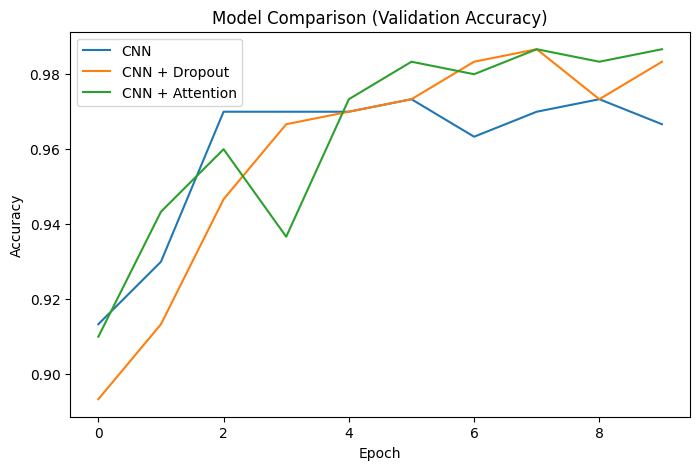

In [19]:
plt.figure(figsize=(8,5))

plt.plot(cnn_acc, label="CNN")
plt.plot(drop_acc, label="CNN + Dropout")
plt.plot(attn_acc, label="CNN + Attention")

plt.title("Model Comparison (Validation Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## 14. Save Models

In [20]:
os.makedirs("../models", exist_ok=True)

torch.save(cnn_model.state_dict(), "../models/cnn.pth")
torch.save(drop_model.state_dict(), "../models/cnn_dropout.pth")
torch.save(attn_model.state_dict(), "../models/cnn_attention.pth")

## 15. Summary

We trained and compared three models:
- CNN (baseline)
- CNN with Dropout
- CNN with Attention

We tracked performance over epochs and observed differences in learning behavior, which will be further analyzed in the testing and explainability phase.